# Comprehensive Exploratory Data Analysis (EDA)

This notebook explores the three distinct datasets in our project:
1. **Binary Classification Dataset** (25,000 labeled reviews: Positive/Negative)
2. **Continuous Regression Dataset** (25,000 labeled reviews: 1 to 10 Ratings)
3. **Unsupervised Dataset** (50,000 unlabelled reviews)

We will compare these datasets side-by-side to understand text length distributions, class balance, and natural sentiment in the wild!


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

# Set parameters
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dhanu\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 1. Load All Datasets

In [21]:
print("Loading Classification Data...")
df_cls = pd.read_csv("../processed_for_binary_classification/imdb_train.csv")

print("Loading Regression Data...")
df_reg = pd.read_csv("../processed_for_regression/imdb_regression_train.csv")

print("Loading Unsupervised Data...")
df_unsup = pd.read_csv("../processed_for_clustering/imdb_unsup.csv")

print(f"\nClassification: {df_cls.shape}")
print(f"Regression    : {df_reg.shape}")
print(f"Unsupervised  : {df_unsup.shape}")


Loading Classification Data...
Loading Regression Data...
Loading Unsupervised Data...

Classification: (25000, 2)
Regression    : (25000, 2)
Unsupervised  : (50000, 2)


## 2. Target Distributions (Classification vs. Regression)
Let's see how our target variables are distributed. We will plot the 50/50 binary split next to the 1-10 rating histogram.


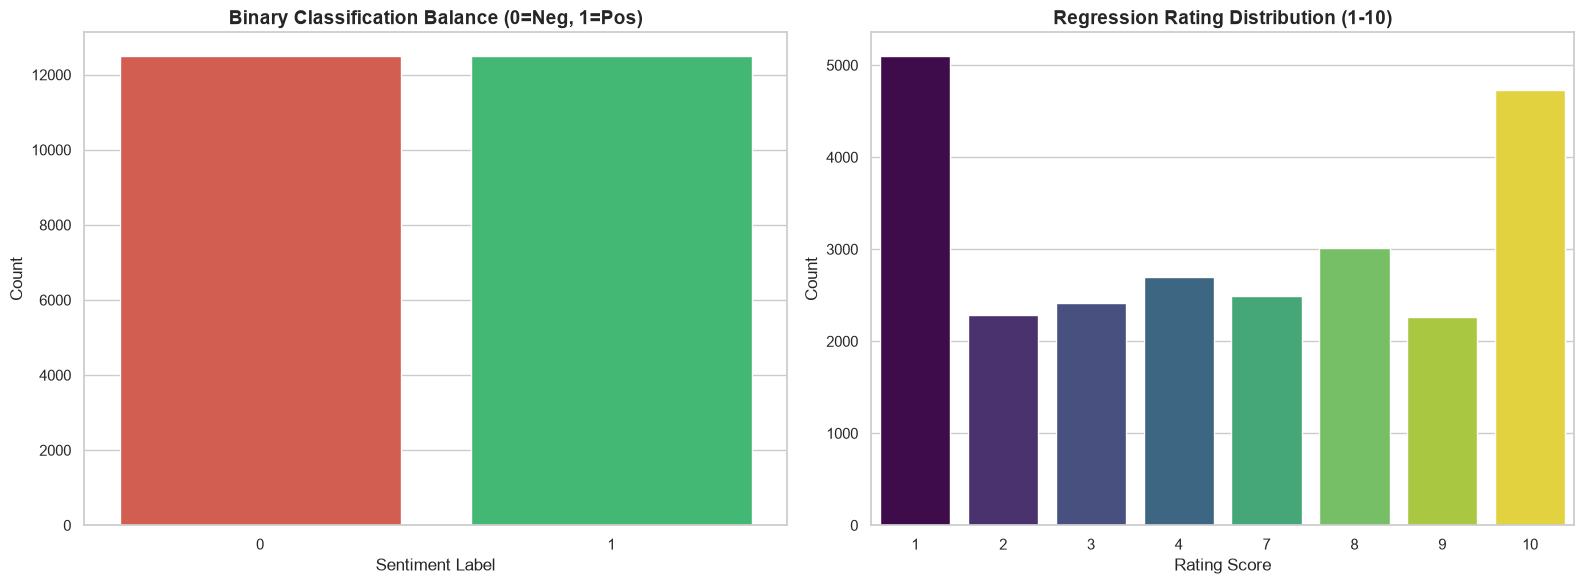

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Binary Classification
sns.countplot(data=df_cls, x='label', hue='label', legend=False, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title("Binary Classification Balance (0=Neg, 1=Pos)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Sentiment Label")
axes[0].set_ylabel("Count")

# Subplot 2: Regression Rating Distribution
sns.countplot(data=df_reg, x='rating', hue='rating', legend=False, ax=axes[1], palette="viridis")
axes[1].set_title("Regression Rating Distribution (1-10)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Rating Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 3. Review Length Analysis (Across All 3 Datasets)
Are unlabelled reviews longer? Do people write longer reviews when they hate a movie (1) vs when they love it (10)? Let's compare!


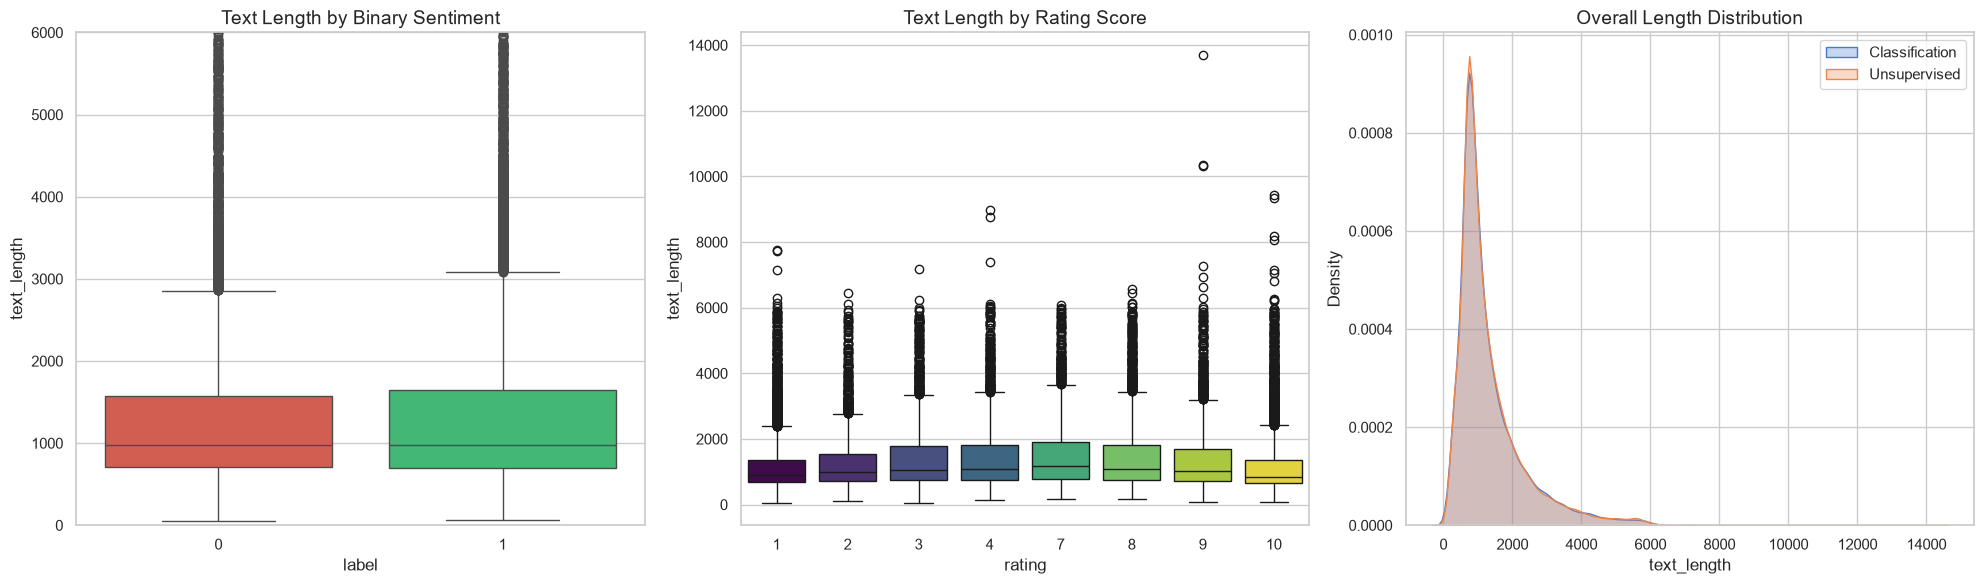

In [23]:
# Calculate string lengths
df_cls['text_length'] = df_cls['text'].str.len()
df_reg['text_length'] = df_reg['text'].str.len()
df_unsup['text_length'] = df_unsup['text'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# 1. Length by Binary Class
sns.boxplot(data=df_cls, x='label', y='text_length', hue='label', legend=False, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title("Text Length by Binary Sentiment", fontsize=14)
axes[0].set_ylim(0, 6000) # Cap at 6000 for visibility

# 2. Length by Rating
sns.boxplot(data=df_reg, x='rating', y='text_length', hue='rating', legend=False, ax=axes[1], palette="viridis")
axes[1].set_title("Text Length by Rating Score", fontsize=14)

# 3. Length Distribution (Unsupervised vs All)
sns.kdeplot(df_cls['text_length'], label='Classification', fill=True, alpha=0.3, ax=axes[2])
sns.kdeplot(df_unsup['text_length'], label='Unsupervised', fill=True, alpha=0.3, ax=axes[2])
axes[2].set_title("Overall Length Distribution", fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()


## 4. Word Clouds (Positive vs. Negative)
Let's visually extract the most dominant words for Positive and Negative sentiments from the classification dataset.


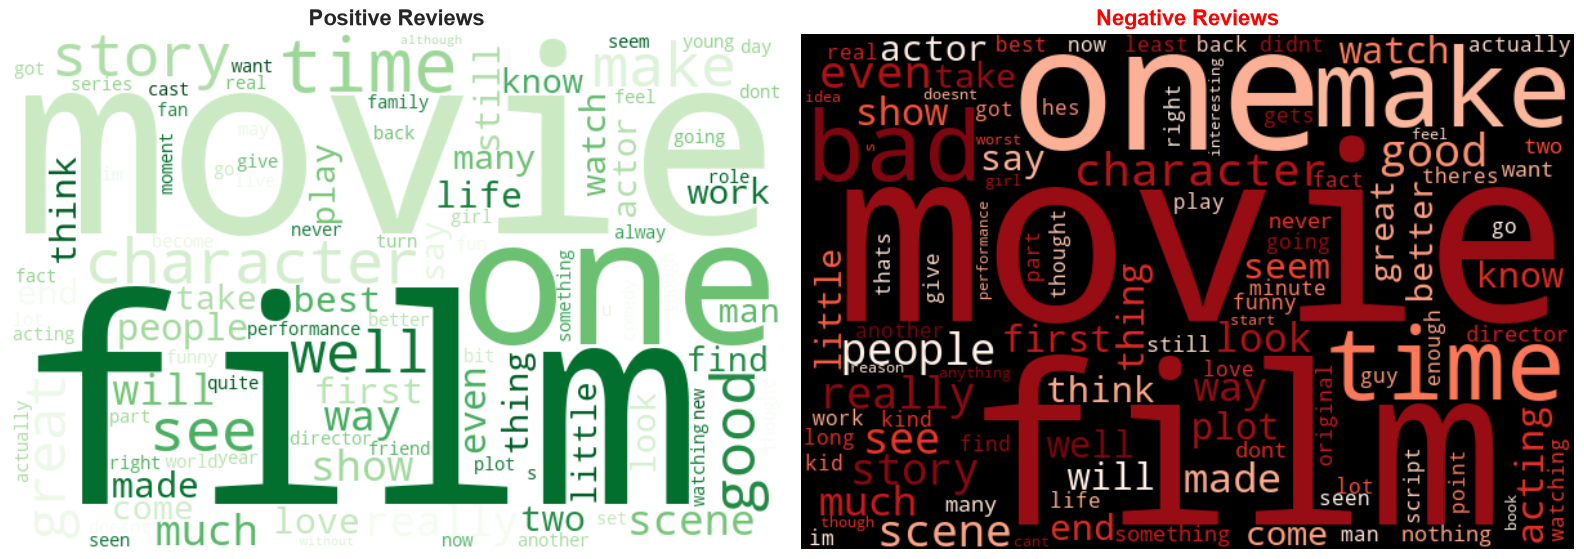

In [24]:
# Basic text cleaning for wordcloud
def clean_for_wc(text):
    text = re.sub(r'<[^>]*>', ' ', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

pos_text = " ".join(df_cls[df_cls['label'] == 1]['text'].sample(2000, random_state=42).apply(clean_for_wc))
neg_text = " ".join(df_cls[df_cls['label'] == 0]['text'].sample(2000, random_state=42).apply(clean_for_wc))

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=600, height=400, background_color='black', colormap='Reds', max_words=100).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title("Positive Reviews", fontsize=16, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title("Negative Reviews", fontsize=16, fontweight='bold', color='red')
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 5. High-Impact Words (Regression Score Mapping)
What is the average 1-10 rating of a review if it contains the word "masterpiece"? What if it contains "awful"? 
Let's map specific vocabulary to their continuous regression score!


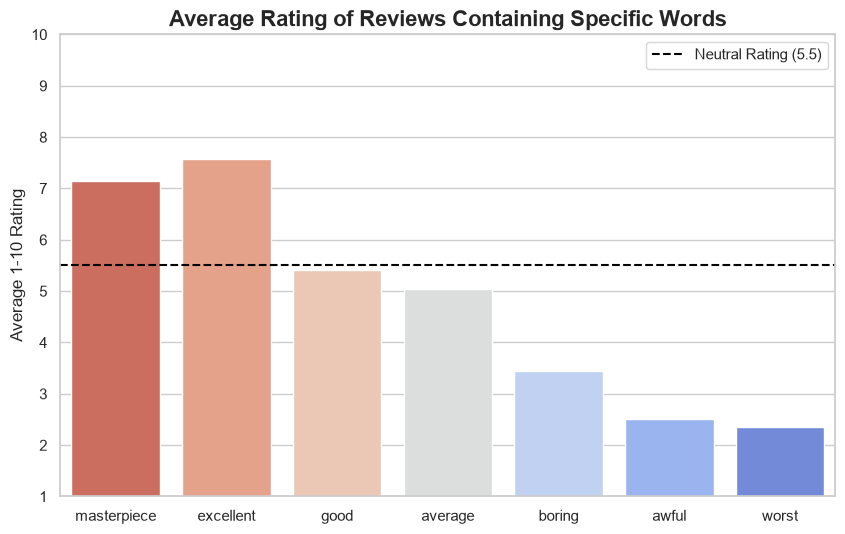

In [25]:
keywords = ['masterpiece', 'excellent', 'good', 'average', 'boring', 'awful', 'worst']
avg_ratings = []

df_reg['clean_text'] = df_reg['text'].str.lower()

for word in keywords:
    # Find rows containing the word
    mask = df_reg['clean_text'].str.contains(r'\b' + word + r'\b', na=False)
    avg_rating = df_reg[mask]['rating'].mean()
    avg_ratings.append(avg_rating)

plt.figure(figsize=(10, 6))
sns.barplot(x=keywords, y=avg_ratings, hue=keywords, legend=False, palette="coolwarm_r")
plt.axhline(5.5, color='black', linestyle='--', label='Neutral Rating (5.5)')
plt.title("Average Rating of Reviews Containing Specific Words", fontsize=16, fontweight='bold')
plt.ylabel("Average 1-10 Rating")
plt.ylim(1, 10)
plt.legend()
plt.show()


## 6. Sentiment "In the Wild" (Unsupervised Dataset)
Since the unsupervised dataset has no labels, we will use VADER (a pre-trained lexicon) to predict sentiment on a sample of 5,000 reviews. 
This will tell us if natural, unlabelled movie reviews lean Positive or Negative.


Calculating VADER sentiment scores...


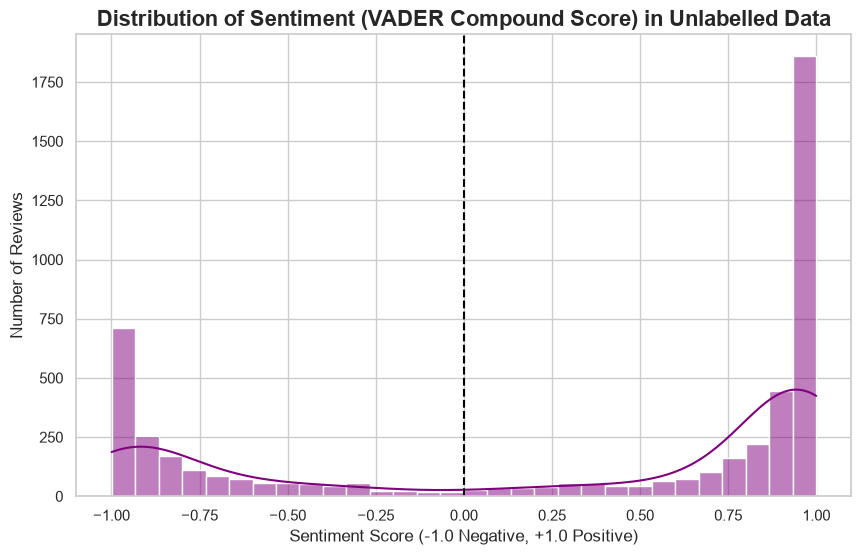

Percentage of Positively-leaning reviews in Unsupervised Data: 65.0%


In [26]:
sia = SentimentIntensityAnalyzer()

# Sample 5,000 reviews to save time
sample_unsup = df_unsup.sample(5000, random_state=42).copy()

def get_vader_compound(text):
    # Quick strip of HTML
    text = re.sub(r'<[^>]*>', ' ', str(text))
    return sia.polarity_scores(text)['compound']

print("Calculating VADER sentiment scores...")
sample_unsup['vader_score'] = sample_unsup['text'].apply(get_vader_compound)

plt.figure(figsize=(10, 6))
sns.histplot(sample_unsup['vader_score'], bins=30, kde=True, color='purple')
plt.title("Distribution of Sentiment (VADER Compound Score) in Unlabelled Data", fontsize=16, fontweight='bold')
plt.xlabel("Sentiment Score (-1.0 Negative, +1.0 Positive)")
plt.ylabel("Number of Reviews")
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Proportion
pos_prop = (sample_unsup['vader_score'] > 0).mean()
print(f"Percentage of Positively-leaning reviews in Unsupervised Data: {pos_prop:.1%}")


## 7. N-Gram Analysis (Top Bigrams)
Single words are great, but two-word phrases (Bigrams) often carry much more context (e.g., "waste of time" vs "highly recommend"). 
Let's look at the top 10 bigrams for Positive and Negative reviews!


Calculating Positive Bigrams...
Calculating Negative Bigrams...


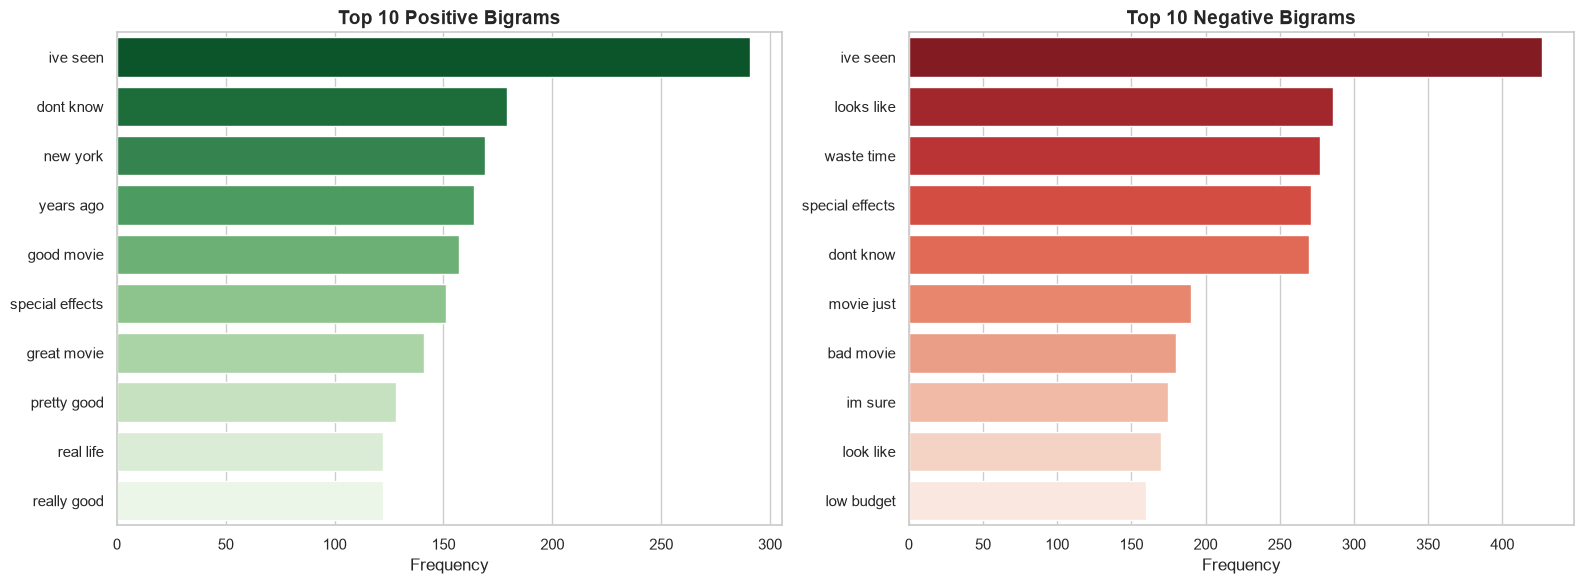

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Sample 5000 reviews from each class for speed
pos_corpus = df_cls[df_cls['label'] == 1]['text'].sample(5000, random_state=42).apply(clean_for_wc)
neg_corpus = df_cls[df_cls['label'] == 0]['text'].sample(5000, random_state=42).apply(clean_for_wc)

print("Calculating Positive Bigrams...")
top_pos_bigrams = get_top_bigrams(pos_corpus)
print("Calculating Negative Bigrams...")
top_neg_bigrams = get_top_bigrams(neg_corpus)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=[val[1] for val in top_pos_bigrams], y=[val[0] for val in top_pos_bigrams], 
            ax=axes[0], hue=[val[0] for val in top_pos_bigrams], legend=False, palette='Greens_r')
axes[0].set_title("Top 10 Positive Bigrams", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Frequency")

sns.barplot(x=[val[1] for val in top_neg_bigrams], y=[val[0] for val in top_neg_bigrams], 
            ax=axes[1], hue=[val[0] for val in top_neg_bigrams], legend=False, palette='Reds_r')
axes[1].set_title("Top 10 Negative Bigrams", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()


## 8. Meta-Features Analysis (Do angry reviewers shout more?)
Let's see if there is a correlation between the 1-10 rating score and how people write. Do 1-star reviews use more exclamation marks (`!!!`) or ALL CAPS words compared to 10-star reviews?


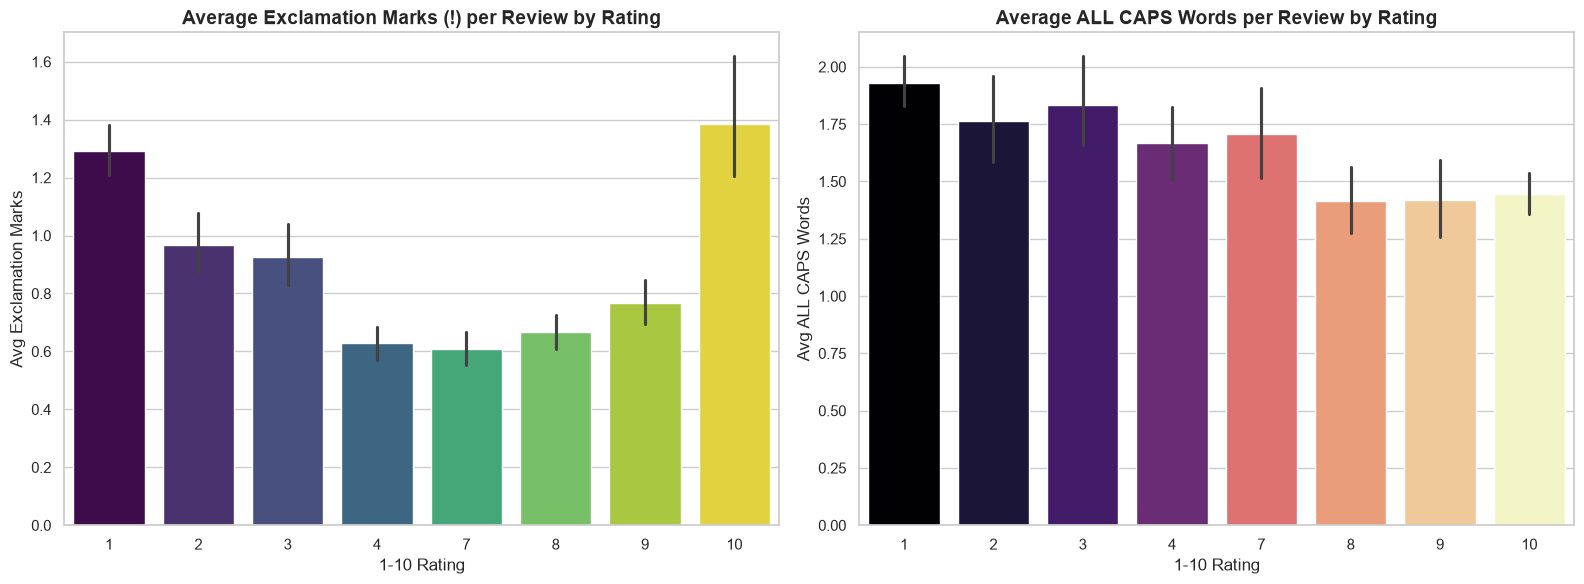

In [28]:
# Count exclamation marks
df_reg['exclamation_count'] = df_reg['text'].apply(lambda x: x.count('!'))

# Count ALL CAPS words (words with > 2 letters that are entirely uppercase)
df_reg['caps_count'] = df_reg['text'].apply(lambda x: len(re.findall(r'\b[A-Z]{2,}\b', x)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Exclamation Marks vs Rating
sns.barplot(data=df_reg, x='rating', y='exclamation_count', ax=axes[0], hue='rating', legend=False, palette='viridis')
axes[0].set_title("Average Exclamation Marks (!) per Review by Rating", fontsize=14, fontweight='bold')
axes[0].set_xlabel("1-10 Rating")
axes[0].set_ylabel("Avg Exclamation Marks")

# ALL CAPS vs Rating
sns.barplot(data=df_reg, x='rating', y='caps_count', ax=axes[1], hue='rating', legend=False, palette='magma')
axes[1].set_title("Average ALL CAPS Words per Review by Rating", fontsize=14, fontweight='bold')
axes[1].set_xlabel("1-10 Rating")
axes[1].set_ylabel("Avg ALL CAPS Words")

plt.tight_layout()
plt.show()
